In [1]:
import os 
import numpy as np
import pandas as pd
import json
from nilearn import plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.stats import spearmanr
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

#import plotly.express as px

plt.style.use('seaborn-v0_8-dark')

In [2]:
col_pc = {0:"#0072B2", 1:"#D55E00", 2:"#009E73", 4:"#009E73"}

from matplotlib.colors import LinearSegmentedColormap

cmap_pc0 = LinearSegmentedColormap.from_list(
    "pc0_blue",
    ["#FFFFFF", "#56B4E9", "#0072B2", "#003F5C"]
)

cmap_pc1 = LinearSegmentedColormap.from_list(
    "pc1_orange",
    ["#FFFFFF", "#F8B195", "#D55E00", "#7F2704"]
)

cmap_pc2 = LinearSegmentedColormap.from_list(
    "pc2_green",
    ["#FFFFFF", "#7BC8A4", "#009E73", "#004D40"]
)
cmap_pcs = [cmap_pc0, cmap_pc1, cmap_pc2]


In [3]:
from src.decomposition import ConcatPCA,PlotTimeSerie, PlotCompoIndividual, CompoThr, DataTransformationM1
from src.preproc import TFRmEvents
from src.setting import GetInfo, ExcludSubj, get_data_grp
from src.config import FREQ_BAND, OUT_PATH, COL_REG

tfr_path = OUT_PATH+ '/Data_longWOBS_full'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
interesting_ev = [0, 1]
event_idx = {0: 'Old', 1:'New'}
color_event = {0: 'b', 1:'r'}

print('Subject number : ', len(subj_included))

coord, areas, elect_list, subj_list, region = GetInfo(subj_included, data_path=tfr_path)
data_grp = get_data_grp(subj_included, return_subj=False, data_path=tfr_path, polarity_cor=(False,0), type_data='tfr')

Subject number :  30


In [4]:
json_file = f'{tfr_path}/{subj_included[0]}_info.json'
with open(json_file) as json_data:
    d = json.load(json_data)
    time=np.array(d['time_tfr'])
    time_epoch = np.array(d['time_epoch'])

In [10]:
nb_compo=5
method = 'concat'
grp_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_{method}/grp_{method}_Compo_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')

#### INTRO

In [12]:
# THR THE DATA 
df_data_all={}

for band in FREQ_BAND :   
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    data_thr = CompoThr(data, replace = 0) # np.nan)
    df_data = pd.DataFrame(data_thr.T)
    df_data.loc[:, ['x', 'y', 'z']] = coord
    df_data.loc[:, ['region']] = [a[0] for a in areas] # regions
    # missing regions 
    df_data.loc[:, 'region'] = df_data.loc[:, 'region'].fillna('NON')

    df_data[[0, 1, 2, 3]] = df_data[[0, 1, 2, 3]].astype(float)
    df_data_all[band] = df_data

    # plt
    #fig, axs = plt.subplots(1, nb_compo, figsize = (15, 3))
    #fig.suptitle(f'Without/with thresholding {band}')
    df = grp_compo.query("freq == @band").set_index('compo').drop(columns = ['freq'])
    df_thr = pd.DataFrame(CompoThr(data, replace=np.nan)).T
    df_thr[[0, 1, 2, 3]] = df_thr[[0, 1, 2, 3]].astype(float)
    df_thr = df_thr.T
    df_thr['compo'] = ['compo' + str(i+1) for i in range(len(df_thr))]
    df_thr= df_thr.set_index('compo')

    #for i, ax in enumerate(axs) : 
    #    df.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'blue', label = 'without')
    #    df_thr.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'red', label='with')   

    #ax.legend()

#### Distribution

In [23]:

PCS = [0, 1, 2]
cmap = ListedColormap(list(COL_REG.values()))

for ib, band in enumerate(['broadband']) : #FREQ_BAND[:1]):
    df_data = df_data_all[band].copy()
    means = (df_data.drop(columns=['x', 'y', 'z']).groupby('region').mean().reindex(COL_REG.keys()).loc[:, PCS])
    df_data_abs = df_data.loc[:, [0, 1, 2, 3, 4]].abs()
    df_data_abs['region'] =[a[0] for a in areas] #regions
    means_abs = (df_data_abs.groupby('region').mean().reindex(COL_REG.keys()).loc[:, PCS])
    count = (df_data_abs.groupby('region').count().reindex(COL_REG.keys()).loc[:, PCS])
    means_norms = means / means_abs
    means_count = means/count
    centroid = df_data[['x', 'y','z', 'region']].groupby('region').mean().reindex(COL_REG.keys())

    for pc in [0, 1, 2] :
        df_data['region_mean'] = df_data['region'].map(means[pc])
        df_data['region_means_abs'] = df_data['region'].map(means_abs[pc])
        df_data['region_means_norm'] = df_data['region'].map(means_norms[pc])
        df_data['region_means_count'] = df_data['region'].map(means_count[pc])

        #fig = plotting.plot_markers(node_coords = df_data[['x', 'y','z']].values, node_size=10,node_values=df_data['region_mean'])
        #fig = plotting.plot_markers(node_coords = abs(df_data[['x', 'y','z']].values), node_size=10, node_values=df_data['region_mean'].values, node_cmap='seismic')


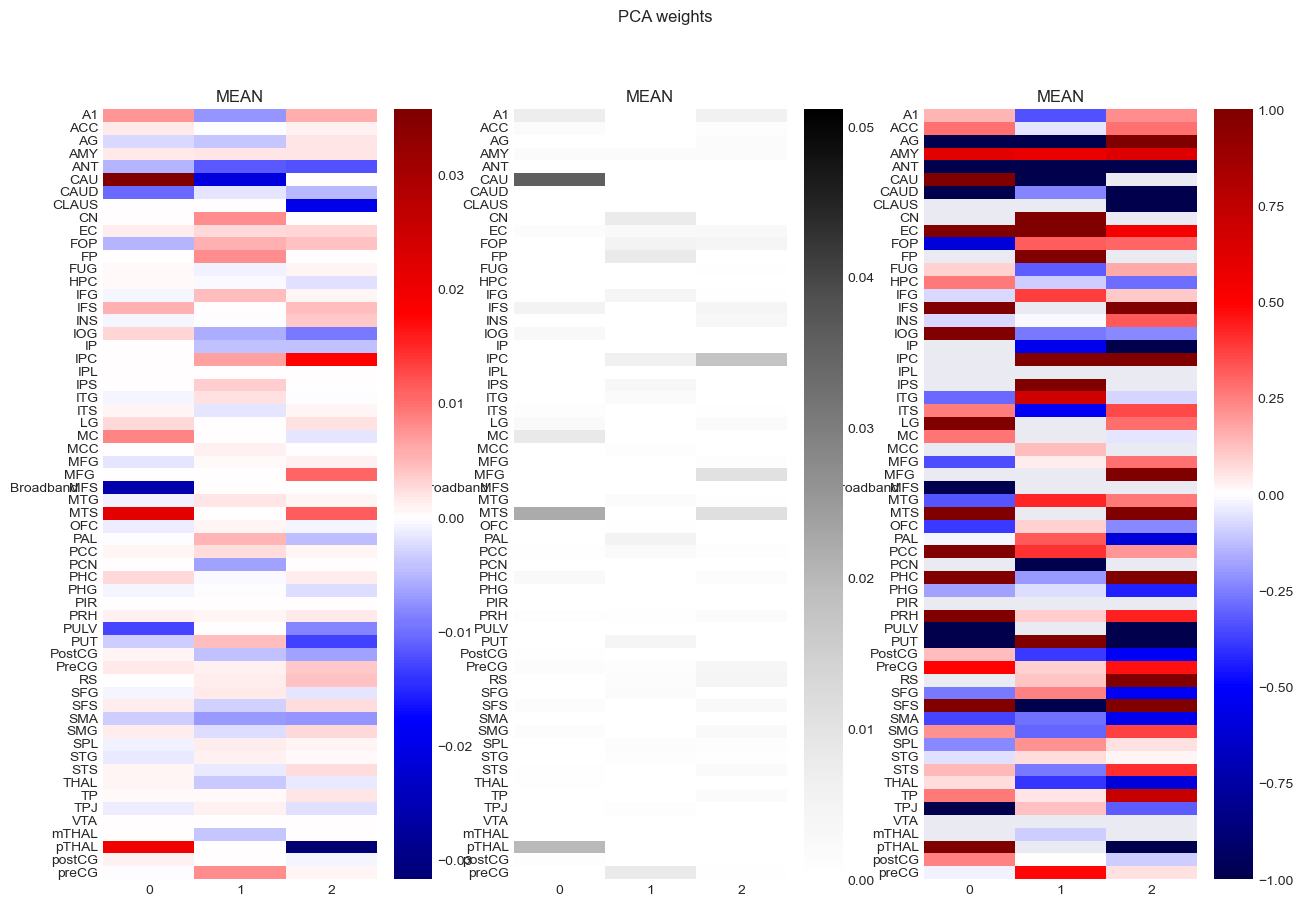

In [24]:
# MEAN OF THE ABS

for band in ['broadband'] : #FREQ_BAND[-1:] :
    fig, ax = plt.subplots(1, 3, figsize = (15, 10), width_ratios=[1/3, 1/3,1/3])
    fig.suptitle('PCA weights')
    df_data = df_data_all[band].copy()

    # MEAN 
    means = df_data.loc[:, [0, 1, 2, 'region']].groupby('region').mean()
    sns.heatmap(means, vmin= np.min(means), vmax = np.max(means), cmap = 'seismic',center=0, ax= ax[0], yticklabels=means.index)
    ax[0].set_title('MEAN')
    ax[0].set_ylabel(band.capitalize().replace('_', ' ') , rotation = 0)

    # Mean ABS
    df_data_abs = df_data.loc[:, [0, 1, 2]].apply(lambda x : np.abs(x))
    df_data_abs['region'] = [a[0] for a in areas]
    means_abs = df_data_abs.groupby('region').mean()    
    sns.heatmap(means, vmin= np.min(means_abs), vmax = np.max(means_abs), cmap = 'Greys', ax= ax[1], yticklabels=means_abs.index)
    ax[1].set_title('MEAN')
    ax[1].set_ylabel(band.capitalize().replace('_', ' ') , rotation = 0)

    # MEAN NORM
    means_norms = means/means_abs
    sns.heatmap(means_norms, vmin= np.min(means_norms), vmax = np.max(means_norms), cmap = 'seismic', ax= ax[2], yticklabels=means_norms.index)
    ax[2].set_title('MEAN')
    ax[2].set_ylabel(band.capitalize().replace('_', ' ') , rotation = 0)

    plt.show()

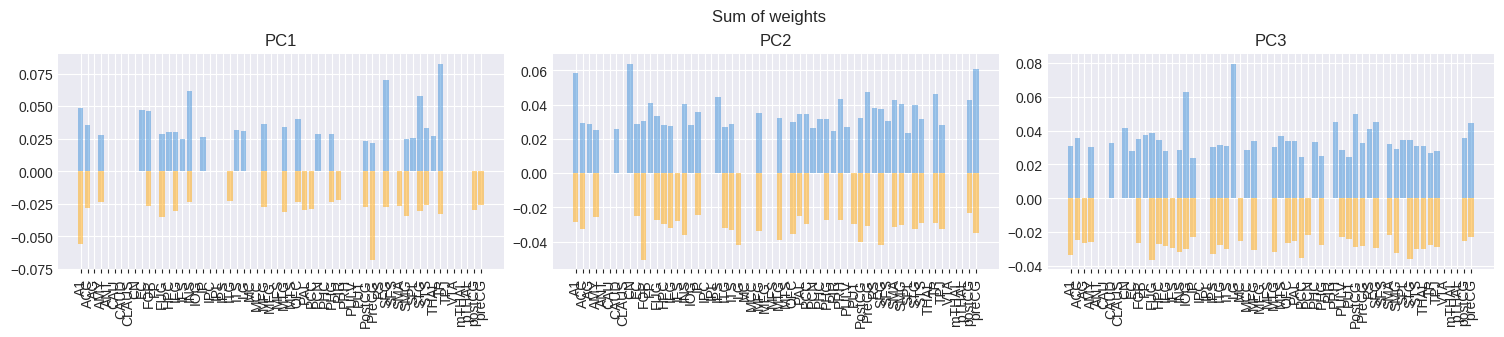

In [14]:
# POS NEG FOR 1 FREQ BAND 
band= 'low_gamma'
fig, axs = plt.subplots(1,3, figsize = (15, 3), sharex=True)
fig.suptitle('Sum of weights')
fig.tight_layout()
largest_list = []
df_data = df_data_all[band]
regions_unique = np.unique(df_data['region'])

for i, ax in enumerate(axs) : 
    pos_sum=pd.DataFrame(df_data[df_data[i] > 0][[i, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())
    neg_sum=pd.DataFrame(df_data[df_data[i] < 0][[i, 'region']].groupby('region').mean().reindex(regions_unique).reset_index())

    ax.bar(regions_unique, pos_sum.loc[:, i], label = band, alpha = 0.5)
    ax.bar(regions_unique, neg_sum.loc[:,i], alpha = 0.5)
    ax.tick_params(axis='x', rotation=90, size = 3)
    ax.set_title('PC' + str(i+1))
    ax.grid()
#plt.close()

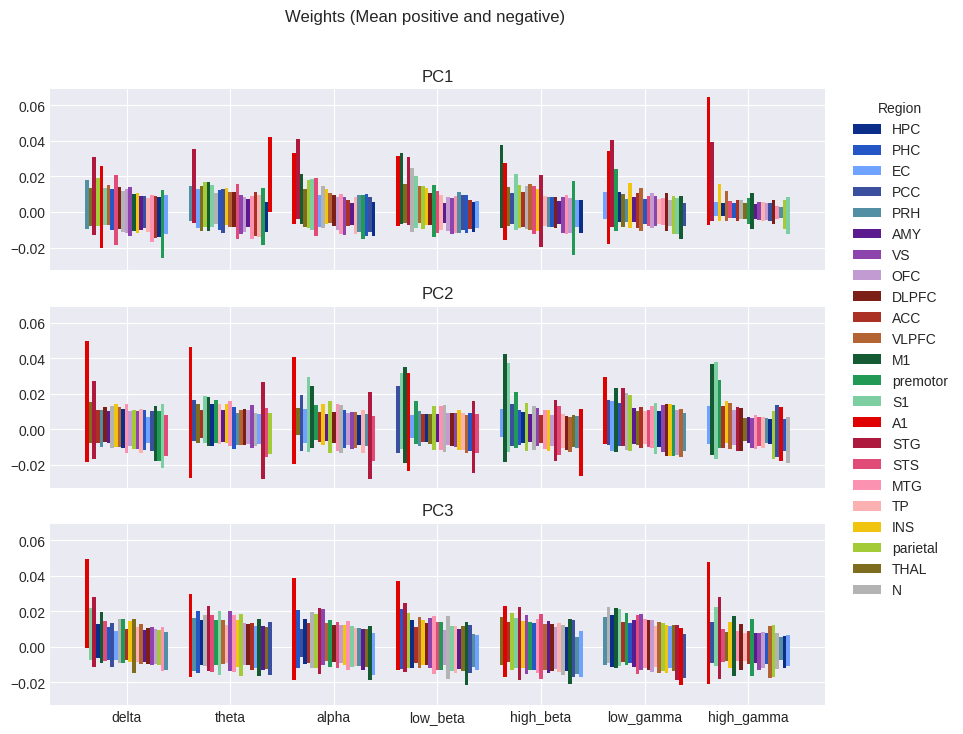

In [15]:
# DAVID'S PLOT 1. ALL THE ROIS WEIGHTS SUM PER ROIS AND FREQ
fig, axs = plt.subplots(3,1, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Weights (Mean positive and negative)')
bands_to_plot = FREQ_BAND
col = COL_REG

bar_width = 0.8 / len(col.keys())


x = np.arange(len(bands_to_plot))

for i_band, band in enumerate(bands_to_plot):

    data = grp_compo.query("freq == @band").drop(columns=['compo', 'freq']).values.copy()
    #data = CompoThr(data, replace=np.nan)

    for PC_use in range(3) :  
        ax =  axs[PC_use]
        if band == 'alpha' and PC_use == 1:
            data[1, :] = -data[1, :]  # flip compo 2 alpha

        df = pd.DataFrame(data.T)
        df.loc[:, 'region'] = region
        df=df.dropna()
        
        pos_sum = (df[df[PC_use] > 0][[PC_use, 'region']].groupby('region').mean().reindex(col.keys()))
        neg_sum = (df[df[PC_use] < 0][[PC_use, 'region']].groupby('region').mean().reindex(col.keys()))
        count = (df[[PC_use, 'region']].groupby('region').count().reindex(col.keys()))
      
        val = (pos_sum[PC_use] + neg_sum[PC_use]) / count[PC_use]
        sorted_regions = val.sort_values(ascending=False).index
        #sorted_regions = col.keys()

        for i_reg, reg in enumerate(sorted_regions):
            offset = (i_reg - (len(col.keys()) - 1) / 2) * bar_width
            #ax.bar(x[i_band] + offset,pos_sum.loc[reg, PC_use]/count.loc[reg, PC_use],color=col[reg],alpha=1,width=bar_width,label=reg if i_band == 0 else None)
            ax.bar(x[i_band] + offset,pos_sum.loc[reg, PC_use],color=col[reg],alpha=1,width=bar_width,label=reg if i_band == 0 else None)

            #ax.bar(x[i_band] + offset,neg_sum.loc[reg, PC_use]/count.loc[reg, PC_use],color=col[reg],alpha=1,width=bar_width)
            ax.bar(x[i_band] + offset,neg_sum.loc[reg, PC_use],color=col[reg],alpha=1,width=bar_width)

        
        ax.grid()
        ax.set_title('PC'+str(PC_use+1))
    ax.set_xticks(x)
    ax.set_xticklabels(bands_to_plot)

from matplotlib.patches import Patch
handles = [Patch(facecolor=col[reg], label=reg)for reg in col.keys()]
axs[0].legend(handles=handles,bbox_to_anchor=(1.02, 1),title='Region')

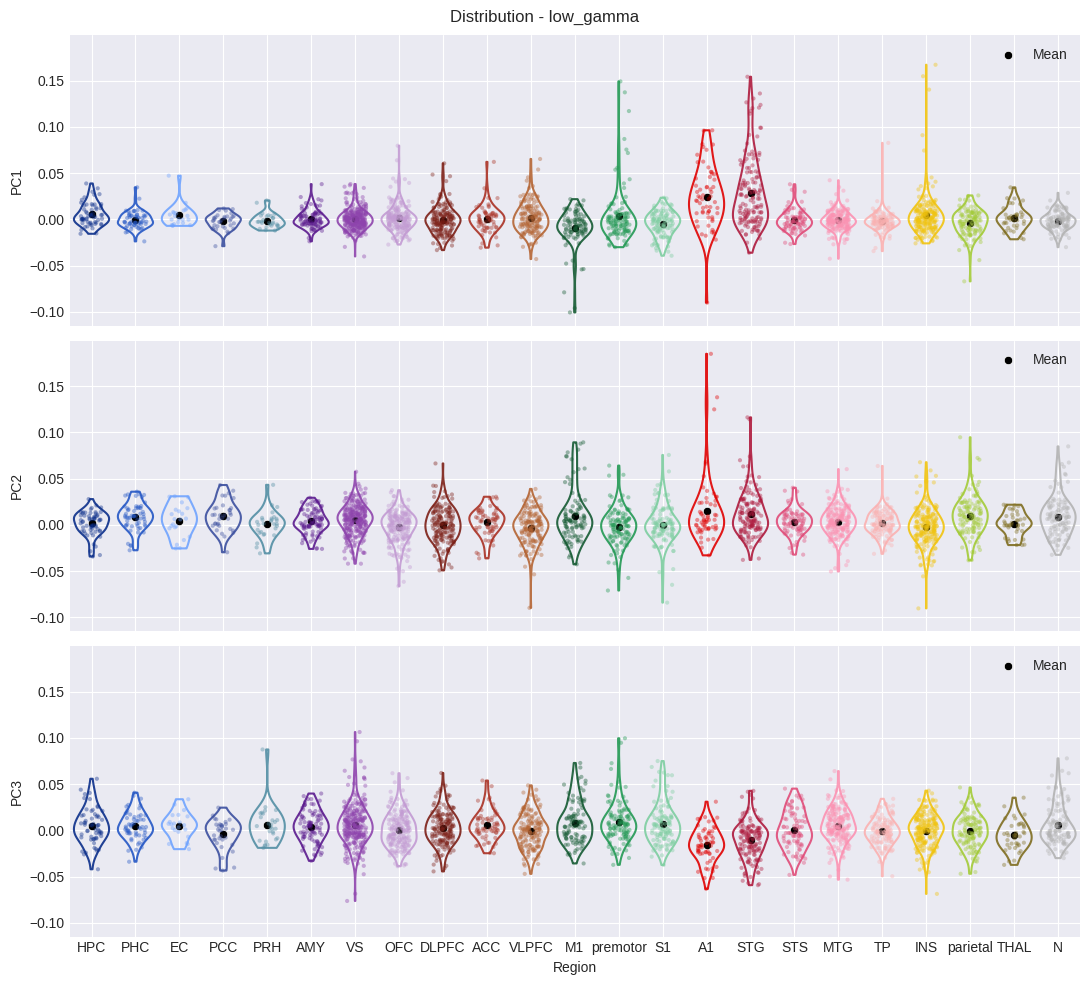

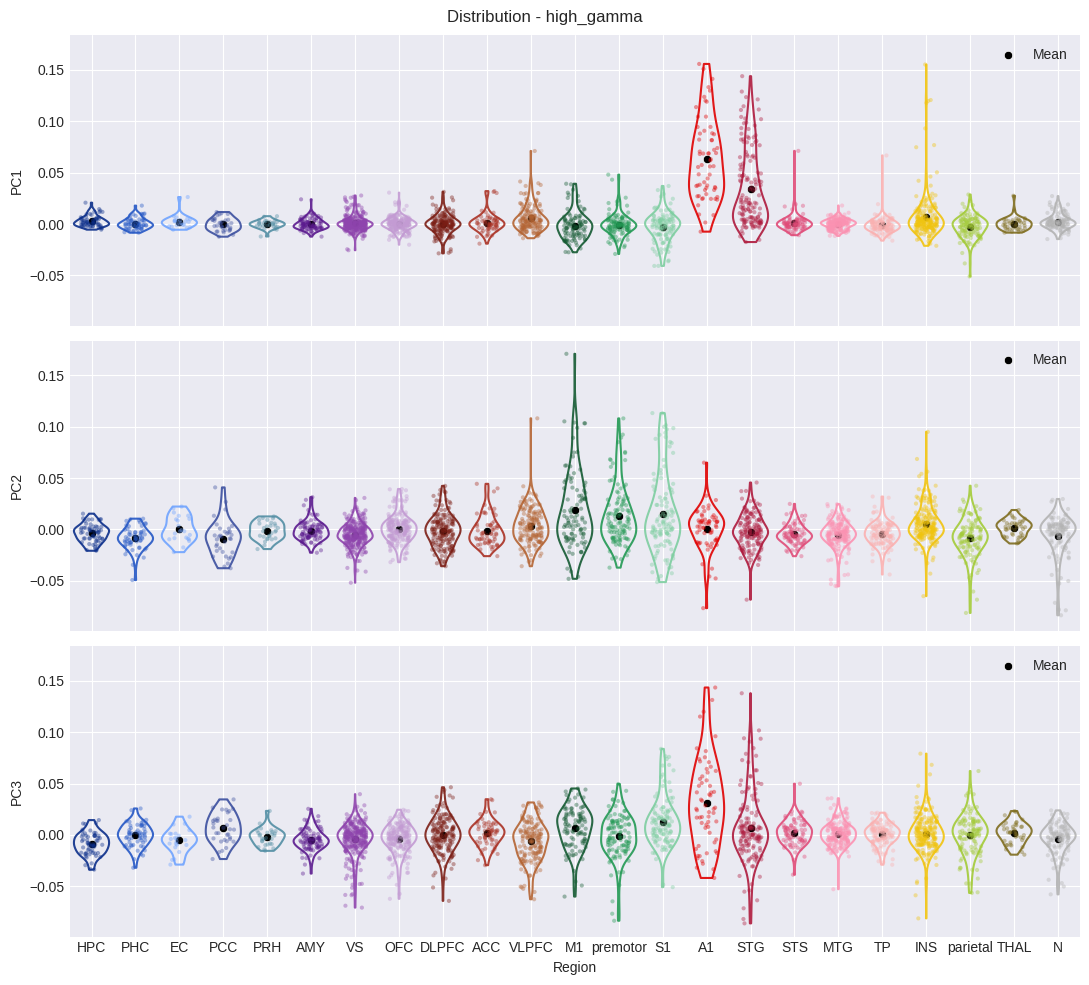

In [16]:
# VIOLIN PLOT FOR THE DISTRIB
regions_unique = np.unique(sorted(region))
col = COL_REG

for i_band, band in enumerate(FREQ_BAND[-2:]):
    fig, axs = plt.subplots(3, 1, figsize=(11, 10), sharex=True, sharey=True)
    fig.suptitle(f'Distribution - {band}')

    data = grp_compo.query("freq == @band").drop(columns=['compo', 'freq']).values
    # data_thr = CompoThr(data, replace=np.nan)

    for PC_use in range(3):
        ax = axs[PC_use]

        if band == 'alpha' and PC_use == 1:
            data[1, :] = -data[1, :]  # flip compo 2 alpha

        df = pd.DataFrame(data.T)
        df['region'] = region
        region_order = list(col.keys())

        means = (
            df.groupby('region', as_index=False)
            .mean()
            .assign(
                region=lambda x: pd.Categorical(
                    x['region'],
                    categories=region_order,
                    ordered=True
                )   
            )
            .sort_values('region')
        )        
        sns.scatterplot(data= means, x='region', c='k', alpha = 1, y=PC_use, ax=ax, markers='-', legend = 'auto')
        sns.violinplot(data =df, y=PC_use, x= 'region', hue = 'region',order=col.keys(), ax =ax, palette=col, alpha = 0.9, cut=0, fill=False, inner = None)        
        sns.stripplot(data=df, x='region',hue = 'region',y=PC_use,order=col.keys(),palette=col,alpha=0.4,jitter=0.25,size=3,ax=ax)
        ax.grid()
        ax.set_ylabel(f'PC{PC_use + 1}')
        ax.legend(['Mean'])

    ax.set_xlabel('Region')
    plt.tight_layout()


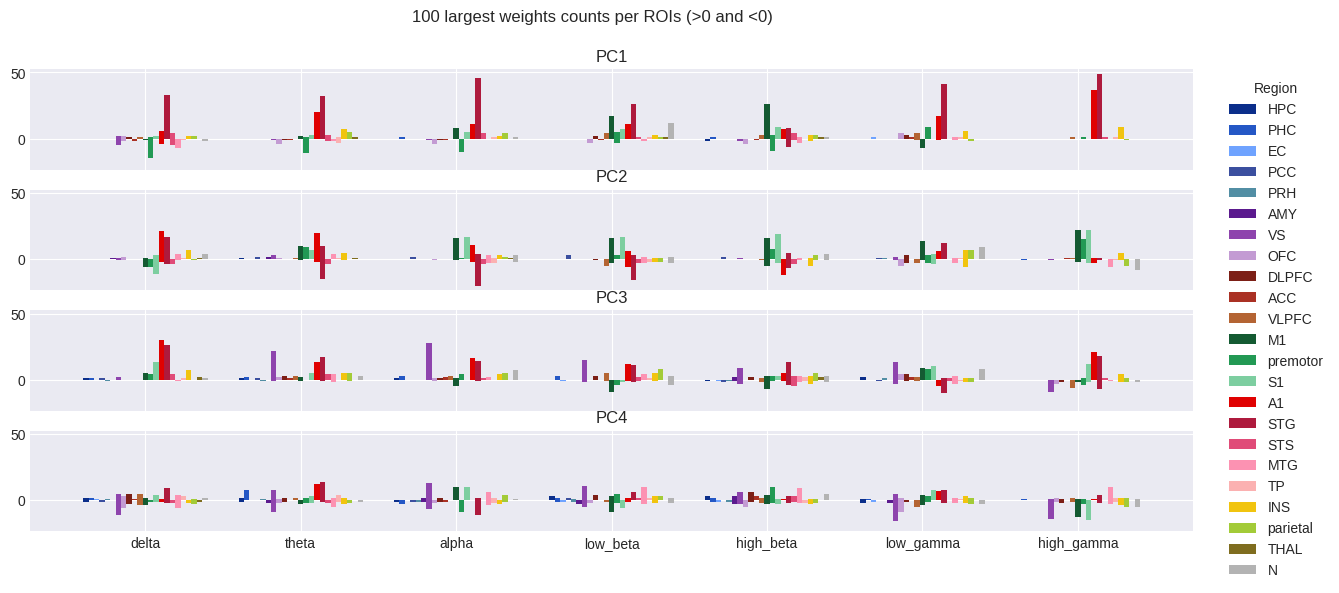

In [17]:
# DAVID'S PLOT 3 -- LARGEST

bar_width = 0.8 / len(col.keys())

fig, axs = plt.subplots(4,1, figsize=(15, 6), sharex=True, sharey=True)
x = np.arange(len(bands_to_plot))
fig.suptitle('100 largest weights counts per ROIs (>0 and <0)')
for i_band, band in enumerate(FREQ_BAND):
    data = grp_compo.query("freq == @band").drop(columns=['compo', 'freq']).values

    for PC_use in range(4) :  
        ax =  axs[PC_use]
        if band == 'alpha' and PC_use == 1:
            data[1, :] = -data[1, :]  # flip compo 2 alpha

        df = pd.DataFrame(data.T)
        index_largest = df.copy().apply(lambda x : abs(x)).nlargest(100, columns = PC_use).index
        df['region'] = region
        df_largest = df.loc[index_largest, :]

        pos_count = (
                df_largest[df_largest[PC_use] > 0][[PC_use, 'region']]
                .groupby('region').count()
                .reindex(col.keys())
            )

        neg_count = (
            df_largest[df_largest[PC_use] < 0][[PC_use, 'region']]
            .groupby('region').count()
            .reindex(col.keys())
        )


        for i_reg, reg in enumerate(col.keys()):
            offset = (i_reg - (len(col.keys()) - 1) / 2) * bar_width

            ax.bar(
                x[i_band] + offset,
                pos_count.loc[reg, PC_use],
                color=col[reg],
                alpha=1,
                width=bar_width,
                label=reg if i_band == 0 else None
            )

            ax.bar(
                x[i_band] + offset,
                - neg_count.loc[reg, PC_use],
                color=col[reg],
                alpha=1,
                width=bar_width
            )
        ax.grid()
        ax.set_title('PC'+str(PC_use+1))
    ax.set_xticks(x)
    ax.set_xticklabels(bands_to_plot)
    axs[0].legend(bbox_to_anchor=(1.02, 1), title='Region')



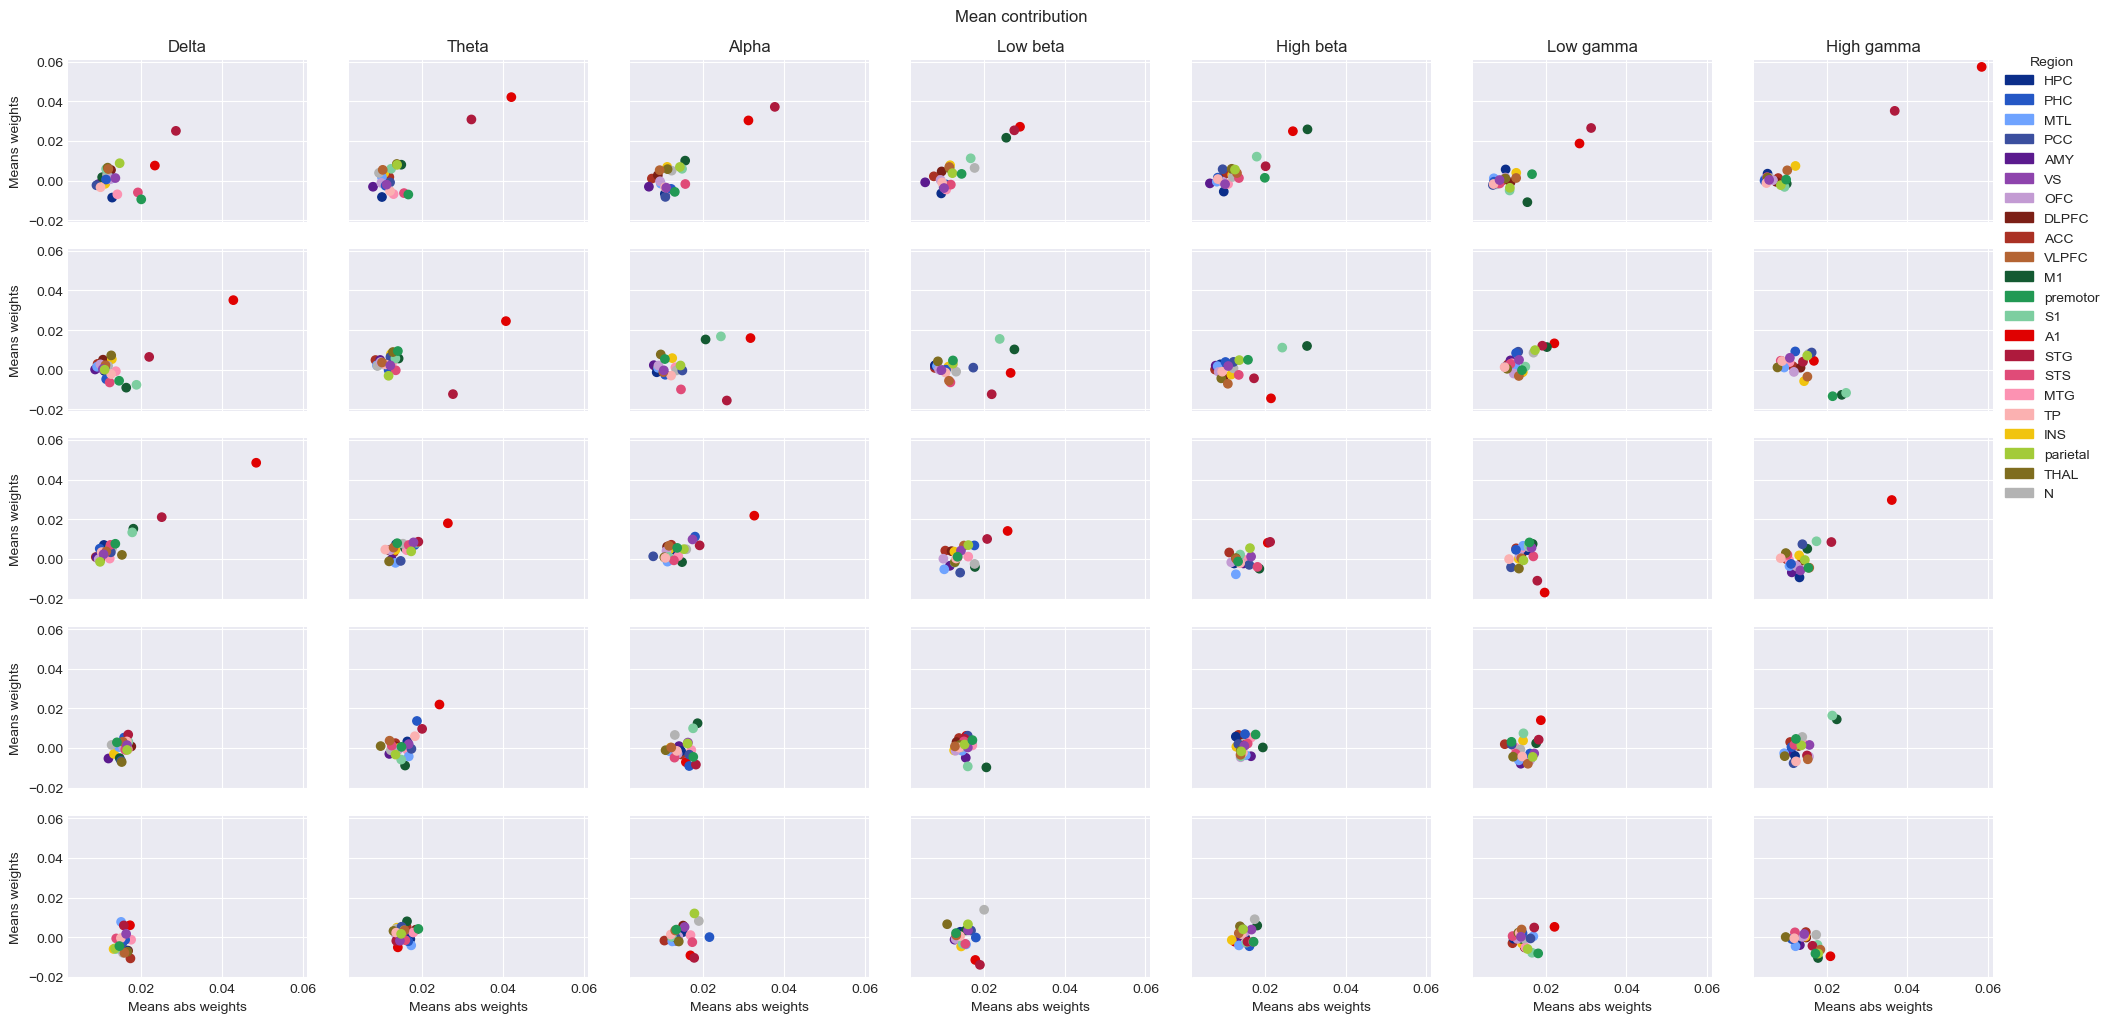

In [284]:
fig, axs = plt.subplots(5,len(FREQ_BAND), figsize = (20, 10), sharex=True, sharey=True)
fig.suptitle('Mean contribution', y=1.001)
fig.tight_layout()
for ib, band in enumerate(FREQ_BAND) :
    df_data = grp_compo.query('freq == @band').drop(columns = ['compo', 'freq']).T
    df_data = df_data.rename(columns = {old:new for old, new in zip(df_data.columns, ['PC'+str(i+1) for i in range(len(df_data.columns))])})
    if band == 'alpha':
        df_data.loc[:, 'PC2'] = -df_data.loc[:, 'PC2']  # flip compo 2 alpha

    df_data_abs = df_data.apply(lambda x : np.abs(x))
    colors = pd.DataFrame(region)[0].map(COL_REG).values

    df_data_abs['region'] = region
    df_data['region'] = region
        
    means = df_data.groupby('region').mean()
    means_abs = df_data_abs.groupby('region').mean()   
    means_norms = means/means_abs
    col_reg = means.reset_index()['region'].map(COL_REG)

    for i, pc in enumerate(means.columns) : 
        axs[i][ib].scatter(means_abs.loc[:, pc], means.loc[:, pc], c=col_reg)
        axs[i][ib].grid()
        axs[-1][ib].set_xlabel('Means abs weights')
        axs[i][0].set_ylabel('Means weights')
    
    axs[0][ib].set_title(band.capitalize().replace('_', ' '))


handles = [
    mpatches.Patch(color=color, label=label, alpha=1)
    for label, color in col.items()
]

axs[0][-1].legend(
    handles=handles,
    title='Region',
    bbox_to_anchor=(1, 1.1),
    loc='best',
    frameon=False
)

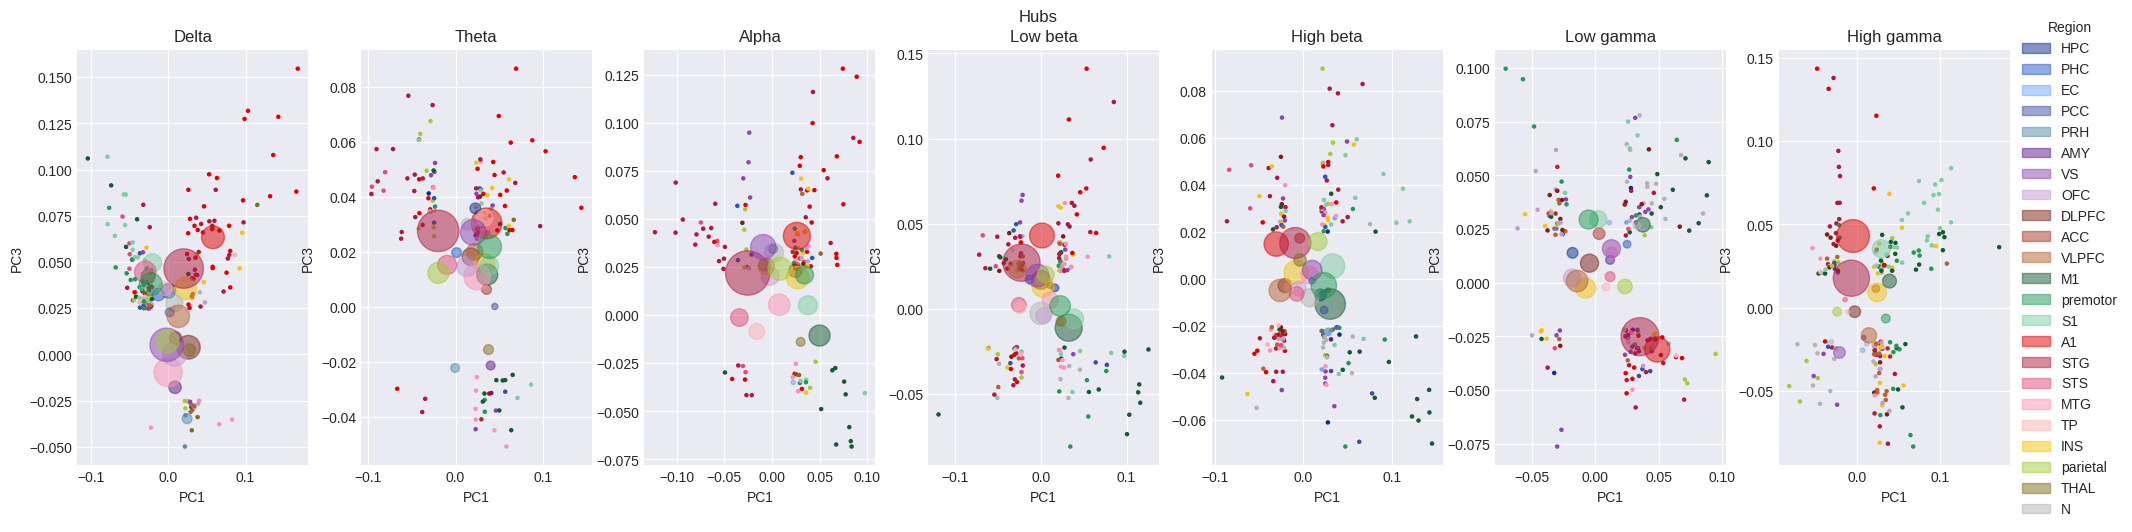

In [19]:
# HUBS
fig, axs = plt.subplots(1, len(FREQ_BAND), figsize = (20, 5), )
fig.suptitle('Hubs')
fig.tight_layout()
for band, ax in zip(FREQ_BAND, axs) :
    data = grp_compo.query('freq == @band').drop(columns = ['compo', 'freq']).values
    if band == 'alpha':
        data[1, :] = -data[1, :]  # flip compo 2 alpha

    colors = pd.DataFrame(region)[0].map(COL_REG).values
    data_thr = CompoThr(data, replace=np.nan)
    data_thr_df = pd.DataFrame(data_thr).T
    data_thr_df.loc[:,'region'] = region

    for i, row in data_thr_df.iterrows() :
        if row[0]==0 and row[1]==0 and row[2] == 0 :
            data_thr_df.loc[i, [0, 1, 2]]=np.nan

            
    data_thr_means = data_thr_df.groupby(by='region').mean() #data_thr_df.groupby(by='region').count()
    data_thr_count = data_thr_df.groupby(by='region').count()

    col_reg = data_thr_means.reset_index()['region'].map(COL_REG)
    ax.scatter(data_thr[1, :], data_thr[2, :], c=colors, s=5)
    ax.scatter(data_thr_means.values.T[1, :], data_thr_means.values.T[2, :], c=col_reg, alpha = 0.5, s=data_thr_count.values.T[0, :]*10)
    ax.grid()
    ax.set_title(band.replace('_', ' ').capitalize())
    ax.set_xlabel('PC2')
    ax.set_ylabel('PC3')

handles = [
    mpatches.Patch(color=color, label=label, alpha=0.5)
    for label, color in COL_REG.items()
]

ax.legend(
    handles=handles,
    title='Region',
    bbox_to_anchor=(1, 1.1),
    loc='upper left',
    frameon=False
)

## DIM RED ?


### PCA ON WEIGHTS

In [31]:
data = grp_compo.set_index('compo').loc[['compo1', 'compo2', 'compo3'], :].reset_index().drop(columns = ['compo', 'freq']).T
data = data.rename(columns={old_name:new_name for old_name, new_name in zip(data.columns, ['PC'+str(i+1) for i in range(len(data.columns))])})

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
data_T = pca.fit_transform(X=data.values[:, :3], )


In [32]:
pca.explained_variance_ratio_

array([0.75678413, 0.17478016, 0.06843571])

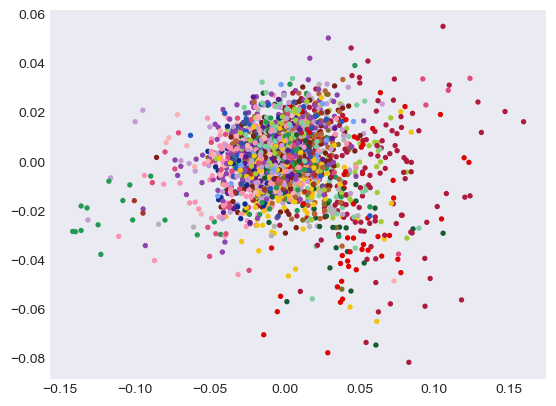

In [34]:
plt.scatter(data_T[:, 0], data_T[:, 1], c=pd.DataFrame(region)[0].map(COL_REG).values, s=8)

### Clustering

In [68]:
data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).T
data.rename(columns={old_name:new_name for old_name, new_name in zip(data.columns, ['PC'+str(i+1) for i in range(len(data.columns))])})

,PC1,PC2,PC3
0,-0.023495,-0.001368,-0.017089
1,-0.018089,0.022201,0.002139
2,-0.016408,-0.010563,-0.019376
3,-0.020159,0.009678,-0.019409
4,0.006522,-0.011203,0.017886
...,...,...,...
2571,-0.000631,0.010601,-0.002613
2572,-0.010916,-0.000641,-0.037884
2573,-0.021702,0.003622,-0.013055
2574,-0.021732,-0.002676,-0.045844


In [ ]:
def PCClustering(freqband = FREQ_BAND, ) :
    models = [KMeans, SpectralClustering, AgglomerativeClustering]
    names =  ['KMeans', 'SpectralClustering', 'AgglomerativeClustering']
    
    df_labels =pd.DataFrame()
    for band in freqband :
        df = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).T
        df.rename(columns={old_name:new_name for old_name, new_name in zip(data.columns, ['PC'+str(i+1) for i in range(len(data.columns))])})
        
        df['area'] = df_data['region']

        scaler = StandardScaler(with_std=False, with_mean=False)
        weight_data_b = scaler.fit_transform(weight_data_b)[:,:2]
        
        for name, model in zip(names, models) : 
            silhouette_avg = []
            range_n_clusters = np.arange(2, 10)
            for n_clusters in range_n_clusters : 
                cl = model(n_clusters)
                cl.fit(weight_data_b)
                cluster_labels = cl.labels_
                silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
            ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
            sil_score = max(silhouette_avg)

            m = model(ncl_best).fit(weight_data_b)
            df['label_' + name] = m.labels_.T
            df_labels[band + '_' +name] =  m.labels_.T

            for ic, c in enumerate(['compo1', 'compo2']) : 
                df_labels[band + '_' + c]= weight_data_b[:,ic ]

    df_labels.to_csv(OUT_PATH + f'/grpPCA/supsubj_{method}/labelsTHR.csv')


In [59]:

models = [KMeans, SpectralClustering, AgglomerativeClustering]
names =  ['KMeans', 'SpectralClustering', 'AgglomerativeClustering']

df_labels =pd.DataFrame()
for band in FREQ_BAND[:3] :
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T

    df= pd.DataFrame(weight_data_b[:, 0]).rename(columns = {0: 'compo1'})
    df.loc[:, 'compo2'] = weight_data_b[:, 1]
    df.loc[:, 'compo3'] = weight_data_b[:, 2]
    df['area'] = df_data['region']

    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)[:,:2]
    
    for name, model in zip(names, models) : 
        silhouette_avg = []
        range_n_clusters = np.arange(2, 10)
        for n_clusters in range_n_clusters : 
            cl = model(n_clusters)
            cl.fit(weight_data_b)
            cluster_labels = cl.labels_
            silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
        ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
        sil_score = max(silhouette_avg)

        m = model(ncl_best).fit(weight_data_b)
        df['label_' + name] = m.labels_.T
        df_labels[band + '_' +name] =  m.labels_.T

        for ic, c in enumerate(['compo1', 'compo2']) : 
            df_labels[band + '_' + c]= weight_data_b[:,ic ]

df_labels.to_csv(OUT_PATH + f'/grpPCA/supsubj_{method}/labelsTHR.csv')

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (15, 4))
fig.tight_layout()

mode = 'AgglomerativeClustering'
fig.suptitle(f'{mode} clusters', y=1.1)
cmap = plt.get_cmap('Paired')

for ib, band in enumerate(FREQ_BAND[1:3]):
    colors = np.array([cmap(code) for code in np.unique(df_labels[band + '_'+mode])])
    sns.scatterplot(x=df_labels[band + '_compo1'], y=df_labels[band + '_compo2'], hue = df_labels[band + '_' + mode], ax=ax[ib], palette=colors, s= 20, alpha = 1)
    ax[ib].set_title(band)
    ax[ib].set_xlabel('PC1')
    ax[ib].set_ylabel('PC2')
    ax[ib].legend(np.unique(df_labels[band + '_'+mode]), bbox_to_anchor = (0, -0.2),)


/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/3459922229.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_24218/3459922229.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)


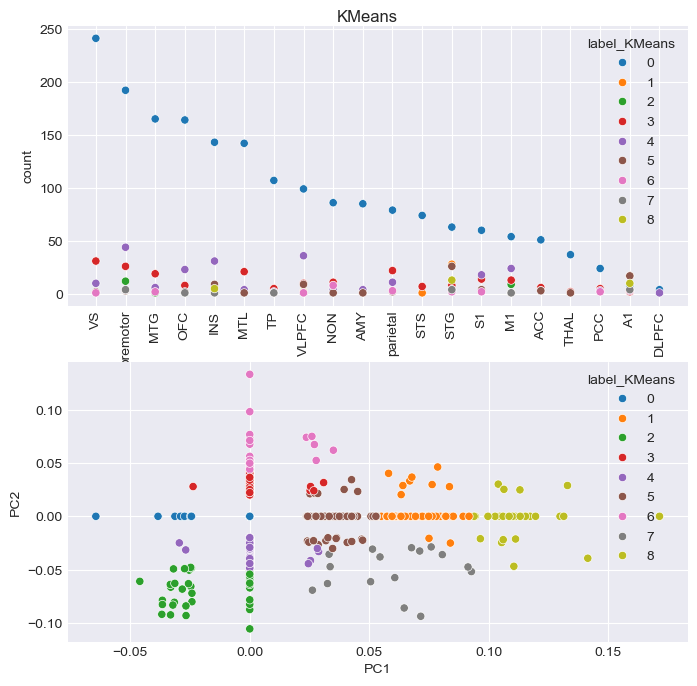

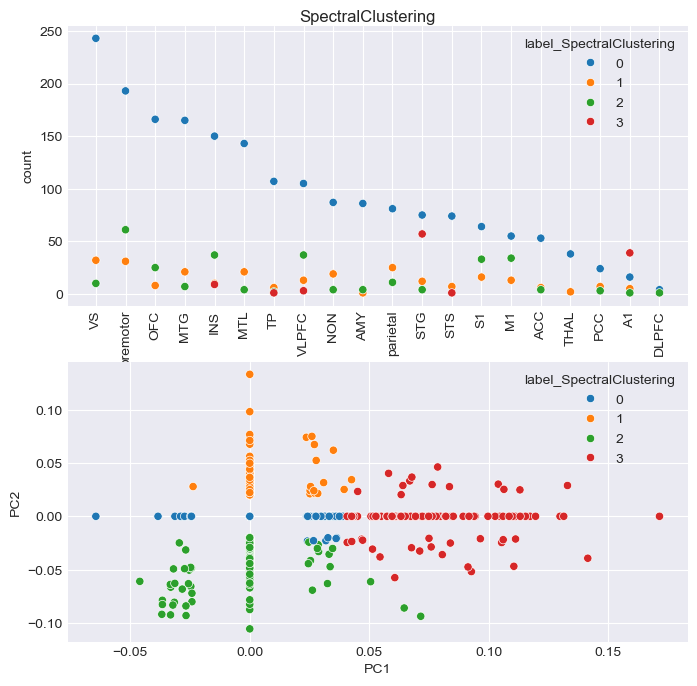

In [ ]:
grp_compo = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_compo_PCA3.csv').drop(columns = 'Unnamed: 0')
data = grp_compo.query("freq == 'high_gamma'").drop(columns = ['compo', 'freq']).values
weight_data_b = CompoThr(data, replace = 0).T

df= pd.DataFrame(weight_data_b[:, 0]).rename(columns = {0: 'compo1'})
df.loc[:, 'compo2'] = weight_data_b[:, 1]
df.loc[:, 'compo3'] = weight_data_b[:, 2]
df['area'] = df_data['region']

scaler = StandardScaler(with_std=False, with_mean=False)
weight_data_b = scaler.fit_transform(weight_data_b)[:,:2]

# model to try 
models = [KMeans, SpectralClustering]
names =  ['KMeans', 'SpectralClustering']

for name, model in zip(names, models) : 
    silhouette_avg = []
    range_n_clusters = np.arange(2, 10)
    for n_clusters in range_n_clusters : 
        cl = model(n_clusters)
        cl.fit(weight_data_b)
        cluster_labels = cl.labels_
        silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
    ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
    sil_score = max(silhouette_avg)

    m = model(ncl_best).fit(weight_data_b)
    df['label_' + name] = m.labels_.T
    df_nnul = df #df[df['compo2'] + df['compo'] !=0 ]

    count = pd.DataFrame(df_nnul.groupby('label_' + name)['area'].value_counts()).reset_index()
    fig, ax = plt.subplots(2, 1, figsize  =(8, 8))
    fig.suptitle(name, y=0.9)

    sns.scatterplot(count, x = 'area', y='count', hue='label_' + name, palette = 'tab10', ax = ax[0])
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)

    sns.scatterplot(data = df_nnul, x='compo1', y='compo2', hue='label_' + name, palette = 'tab10')
    ax[1].set_ylabel('PC2')
    ax[1].set_xlabel('PC1')
    ax[0].grid()
    ax[1].grid()


In [ ]:
df.loc[:,['x', 'y', 'z']] = coord
df_1= df[df['label_KMeans'] == 1]
df_0 = df[df['label_KMeans'] == 0]

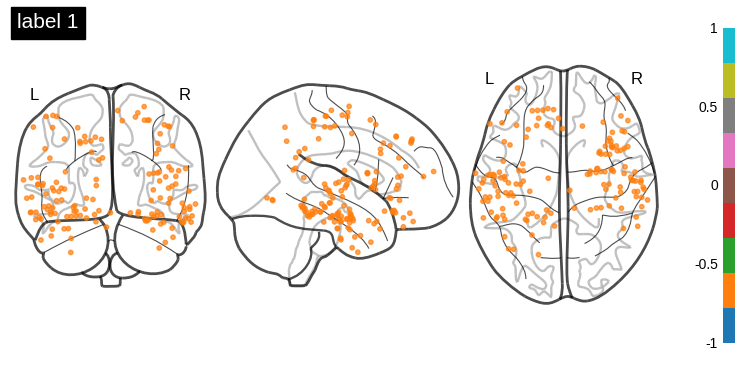

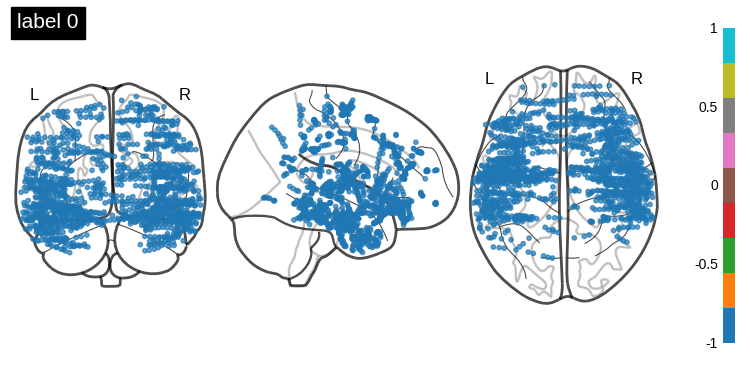

In [ ]:
fig1 = plotting.plot_markers(node_coords = df_1[['x', 'y','z']].values,  node_size=10, node_values=df_1['label_KMeans']-1.7, title=f'label 1', node_cmap='tab10',display_mode='ortho', node_vmin = -1, node_vmax = 1)
fig0 = plotting.plot_markers(node_coords = df_0[['x', 'y','z']].values,  node_size=10, node_values=df_0['label_KMeans'] - 1.5, title=f'label 0',node_cmap='tab10',display_mode='ortho', node_vmin = -1, node_vmax = 1)


In [ ]:
# How much the electrods in the cluster 1 are from ≠ subject?
subj_list=[]
import json 

for subj in subj_included : 
    # Get the number of the electrods per subject 
    json_file = f'{OUT_PATH}/Data/{subj}_info.json'
    with open(json_file) as f:
        info = json.load(f)
        ch_name = info['chnames']

    subj_list.extend([subj] * len(ch_name))

df['subj'] = subj_list


FileNotFoundError: [Errno 2] No such file or directory: 'outs/Data/LL17_info.json'

AttributeError: 'DataFrame' object has no attribute 'subj'

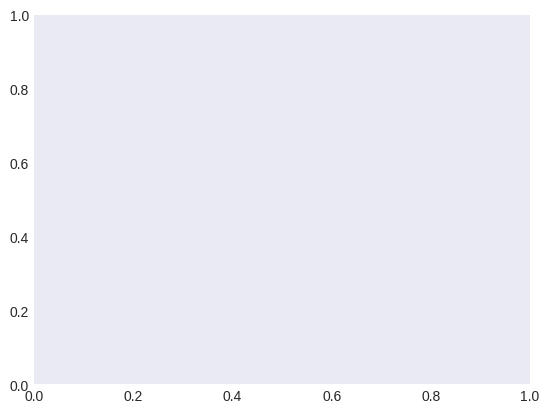

In [ ]:
df_1= df[df['label_KMeans'] == 2]
fig, ax=plt.subplots()
sns.histplot(df_1.subj, ax=ax, color='orange', alpha = 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.show()

In [ ]:
n1, n2, n3 = 20, 20, 20   # example: total = 60

cmap1 = plt.colormaps['tab20']
cmap2 = plt.colormaps['Paired']
cmap4 = plt.colormaps['Pastel1']
cmap3 = plt.colormaps['Set3']
cmap5 = plt.colormaps['Set1']

palette = (
    [cmap1(i) for i in np.linspace(0, 1, 20)] +
    [cmap2(i) for i in np.linspace(0, 1, 10)] +
    [cmap3(i) for i in np.linspace(0, 1, 10)] + 
    [cmap4(i) for i in np.linspace(0, 1, 10)] +
    [cmap5(i) for i in np.linspace(0, 1, 10)]

)

In [ ]:
from utils import REGION


df.loc[:, 'region'] = df.loc[:, 'area'].apply(lambda x : FindRegion(x))

/var/tmp/ipykernel_6908/549368258.py:6: UserWarning: The palette list has more values (60) than needed (1), which may not be intended.
  sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)
/var/tmp/ipykernel_6908/549368258.py:6: UserWarning: The palette list has more values (60) than needed (1), which may not be intended.
  sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)


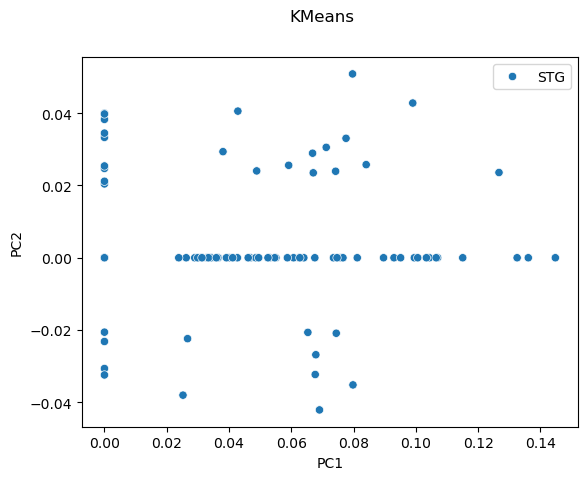

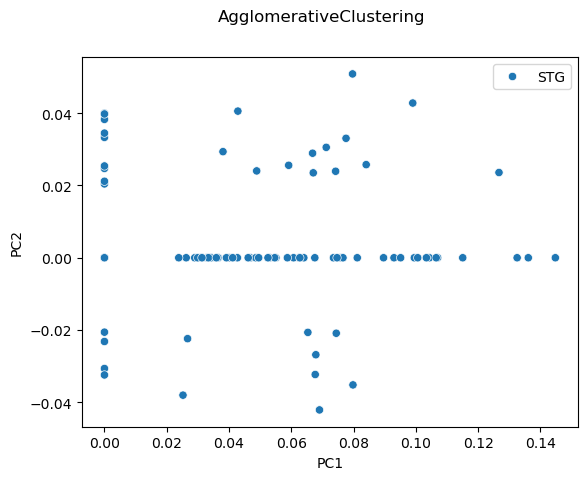

In [ ]:
names =  ['KMeans', 'AgglomerativeClustering']

for name in names : 
    fig, ax = plt.subplots()
    fig.suptitle(name)
    sns.scatterplot(data = df_nnul[df_nnul['region']=='STG'], x='compo', y='compo2', hue='region', palette = palette)
    ax.set_ylabel('PC2')
    ax.set_xlabel('PC1')
    ax.legend(bbox_to_anchor=(1, 1), ncol=1)

In [ ]:
# run kmean clustering on each freq bar and find the optimal numer of clusters
ncl_best = {}
sil_score = {}
labels = pd.DataFrame()
for band in FREQ_BAND : 
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)
    
    silhouette_avg = []
    range_n_clusters = np.arange(2, 10)
    for n_clusters in range_n_clusters : 
        cl = KMeans(n_clusters)
        cl.fit(weight_data_b)
        cluster_labels = cl.labels_
        silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
    ncl_best[band] = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
    sil_score[band] = max(silhouette_avg)
    kmean = KMeans(ncl_best[band]).fit(weight_data_b)
    labels[band] = kmean.labels_.T

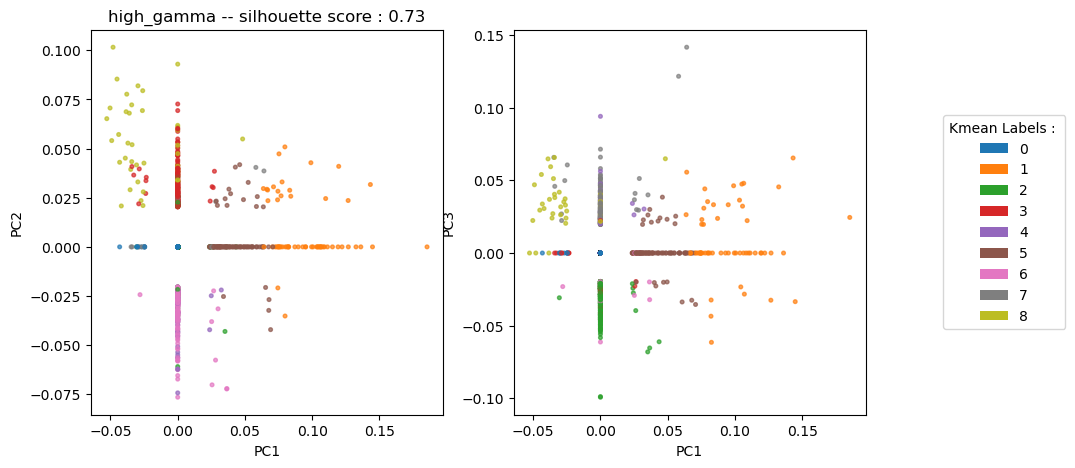

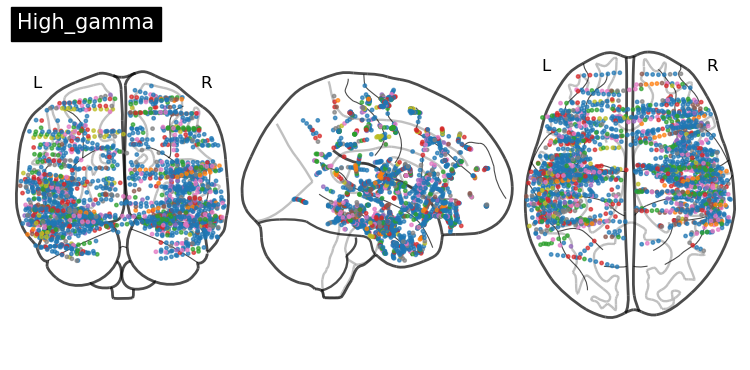

In [ ]:
tfr_path = OUT_PATH + '/Data'
project_path = PROJECT_PATH 

base_cmap = plt.cm.tab10  

for i_b, band in enumerate(['high_gamma']) : #FREQ_BAND) : 
    fig, ax = plt.subplots(1, nb_compo-1, figsize = ((nb_compo-1)*5, 5))
    data = grp_compo.query("freq == @band").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)
    weight_data_b_c1 = weight_data_b[:, 0]

    idx = np.where(labels[band] >=0)[0]
    colors = [base_cmap(i) for i in np.unique(labels[band][idx])]
    custom_cmap = ListedColormap(colors, name=f'tab20_{len(np.unique(labels[band][idx]))}')
    legend_elements = [Patch(facecolor=custom_cmap(i / len(np.unique(labels[band]))), label=str(lbl)) for i, lbl in enumerate(np.unique(labels[band]))]

    for sec_pc in range(nb_compo-1) : 
        weight_data_b_sec = weight_data_b[:, sec_pc +1].T
        ax[sec_pc].scatter(weight_data_b_c1,weight_data_b_sec, c= labels[band], cmap=custom_cmap, alpha=0.7, s=7)
        ax[sec_pc].set_xlabel('PC1')
        ax[sec_pc].set_ylabel('PC' + str(sec_pc+2))
    legend_elements = [Patch(facecolor=custom_cmap(i / len(np.unique(labels[band]))), label=str(lbl)) for i, lbl in enumerate(np.unique(labels[band]))]

    fig = plotting.plot_markers(node_coords=coord_array[idx],node_values=labels[band][idx],node_size=6,node_cmap=custom_cmap,title=band.capitalize(),display_mode='ortho', colorbar=False)
    ax[sec_pc].legend(handles=legend_elements, title="Kmean Labels : ", bbox_to_anchor=(1.2, 0.5), loc='center left')
    ax[0].set_title(band + ' -- silhouette score : ' + str(np.round(sil_score[band], 2)))

    # Brower
    #colors_ = [tuple(custom_cmap(val)) for val in labels[band]] #.flatten()]
    #view = plotting.view_markers(coord_array, marker_color=colors_, marker_size=5, title=band, title_fontsize=25, )
    #view.open_in_browser()

In [ ]:
PC1 = weight_data_b[:, 0]
PC2 = weight_data_b[:, 1]
PC3 = weight_data_b[:, 2]
idx = np.where(labels[band] >=0)[0]
unique_lbls = np.unique(labels[band][idx])
colors = [base_cmap(i) for i in unique_lbls]
custom_cmap = ListedColormap(colors, name=f'tab20_{len(unique_lbls)}')
df = pd.DataFrame({'PC1': PC1[idx],'PC2': PC2[idx],'PC3': PC3[idx],'cluster': labels[band][idx].astype(str)})
fig = px.scatter_3d(df,x='PC1', y='PC2', z='PC3',color='cluster',opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title=f'{band} — silhouette score: {np.round(sil_score[band], 2)}',scene=dict(xaxis_title='PC1',yaxis_title='PC2',zaxis_title='PC3'))
#fig.write_html(f"{OUT_PATH}/grpPCA/supsubj_concat/PC_{band}.html")

In [ ]:
cls_to_try  = np.arange(2, 10)

labels={}
for freq_band_id in FREQ_BAND :
    data = grp_compo.query("freq == @freq_band_id").drop(columns = ['compo', 'freq']).values
    weight_data_b = CompoThr(data, replace = 0).T
    scaler = StandardScaler(with_std=False, with_mean=False)
    weight_data_b = scaler.fit_transform(weight_data_b)

    Z = linkage(weight_data_b, method='ward', metric='euclidean')
    
    # optimize number cluster 
    silhouette_scores = []
    for k in cls_to_try:
        l = fcluster(Z, k, criterion='maxclust')
        sil = silhouette_score(weight_data_b, l)
        silhouette_scores.append(sil)
 
    k = cls_to_try[silhouette_scores.index(max(silhouette_scores))]
    print(freq_band_id, max(silhouette_scores))
    # run 
    labels[freq_band_id] = fcluster(Z, k, criterion='maxclust')


delta 0.625681967250211
theta 0.7293810737973827
alpha 0.6881311119039321
low_beta 0.7010342707483137
high_beta 0.6952769571318203
low_gamma 0.7174519028662647
high_gamma 0.7245696470684544


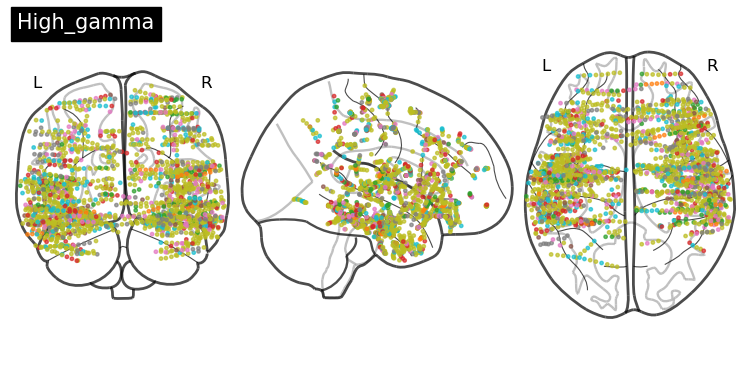

In [ ]:
band = 'high_gamma'
colors_w0 = [base_cmap(i) for i in np.unique(labels[band])]
custom_cmap_w0 = ListedColormap(colors_w0, name=f'tab20_{len(np.unique(labels[band]))}')
idx = np.where(labels[band] !=4 )[0]
fig = plotting.plot_markers(node_coords=coord_array[idx],node_values=labels[band][idx],node_size=6,node_cmap=custom_cmap_w0,title=band.capitalize(),display_mode='ortho', colorbar=False)
